In [39]:
import pandas as pd
import os

def get_unique_excel_headers(folder_path):
    unique_headers = set()

    count=0

    first_last_name = pd.DataFrame([])

    for filename in os.listdir(folder_path):
        if filename.endswith(('.xlsx', '.xls')) and os.path.isfile(os.path.join(folder_path, filename)):
            file_path = os.path.join(folder_path, filename)
            
            try:
                df = pd.read_excel(file_path, header=0)
                unique_headers.update(df.columns.tolist())
                print("\n\n")
                print("** ",filename," **")
                print("- ",df.columns.tolist())

                count+=1
            
            except Exception as e:
                print(f"Could not read file {filename}: {e}")
    
    print("Total number of unique records present : ",len(first_last_name), len(first_last_name.drop_duplicates()))

    print("Count of files present : ", count)            
    return sorted(list(unique_headers))

folder_location = 'Conference_xls_files' 

unique_header_list = get_unique_excel_headers(folder_location)

print("\n--- Summary ---")
print(f"Total Unique Headers Found: {len(unique_header_list)}")
print("List of Unique Headers:")
for header in unique_header_list:
    print(f"- '{header}'")




**  00-May2000conf.xls.xlsx  **
-  ['Salutation', 'First', 'Last', 'SNA Category', 'Title', 'Organization', 'Address', 'City', 'State', 'Zip']



**  00-Nov2000conf.xls.xlsx  **
-  ['Salutation', 'First', 'Last', 'SNA Category', 'Title', 'Organization', 'Address', 'City', 'State', 'Zip']



**  01-May2001conf.xls.xlsx  **
-  ['Salutation', 'First', 'Last', 'SNA Category', 'Title', 'Organization', 'Address', 'City', 'State', 'Zip']



**  01-Nov2001conf.xls.xlsx  **
-  ['Salutation', 'First', 'Last', 'SNA Category', 'Title', 'Organization', 'Address', 'City', 'State', 'Zip']



**  02-May2002conf.xls.xlsx  **
-  ['Salutation', 'First', 'Last', 'SNA Category', 'Title', 'Organization', 'Address', 'City', 'State', 'Zip']



**  02-Nov2002confSNA.xls.xlsx  **
-  ['Salutation', 'First', 'Last', 'SNA Coce', 'Title', 'Organization', 'Address', 'City', 'State', 'Zip']



**  03-June2003conf.xls.xlsx  **
-  ['Salutation', 'First', 'Last', 'SNA Category', 'Title', 'Organization', 'Address', 'C

In [69]:
rename_map={
    'Contact First': 'First',
    'Contact Last': 'Last',
    'LAST': 'Last',
    'Contact Title': 'Title',
    'SNA Code': 'SNA Category',
    'SNA Type': 'SNA Category',
    'SNA Coce': 'SNA Category',
    'Type': 'SNA Category',
    'SNA Categories': 'SNA Category',
    'SNA': 'SNA Category',
    'SNA Categpru': 'SNA Category',
    'SNA Group': 'SNA Category',
    'Sal': 'Salutation',
    'St': 'State',
    'state': 'State',
    'Zip Code': 'Zip',
    'zip': 'Zip',
    'Company Name': 'Organization',
    'Company': 'Organization',
    'Org': 'Organization',
    'Street': 'Address',
    'address': 'Address',
}

In [70]:
all_col_name = list(rename_map.keys()) + list(set(rename_map.values()))
all_col_name

['Contact First',
 'Contact Last',
 'LAST',
 'Contact Title',
 'SNA Code',
 'SNA Type',
 'SNA Coce',
 'Type',
 'SNA Categories',
 'SNA',
 'SNA Categpru',
 'SNA Group',
 'Sal',
 'St',
 'state',
 'Zip Code',
 'zip',
 'Company Name',
 'Company',
 'Org',
 'Street',
 'address',
 'Last',
 'Address',
 'Organization',
 'Zip',
 'State',
 'Title',
 'Salutation',
 'SNA Category',
 'First']

In [71]:
def standardize_and_fill(df, required_cols, fill_value=""):
    existing_cols = [col for col in required_cols if col in df.columns]
    
    missing_cols = [col for col in required_cols if col not in df.columns]
    
    df_subset = df[existing_cols].copy()
    
    if missing_cols:
        for col in missing_cols:
            df_subset[col] = fill_value
            
    return df_subset[required_cols]

In [90]:
import pandas as pd
import os

first_last_name = pd.DataFrame([])

folder_path = 'Conference_xls_files' 

for filename in os.listdir(folder_path):
    if filename.endswith(('.xlsx', '.xls')) and os.path.isfile(os.path.join(folder_path, filename)):
        file_path = os.path.join(folder_path, filename)
        
        def ConcatCol(df, first_last_name):
            df['FileName'] = filename
            df_present = df.rename(columns=rename_map)

            Columns_Needed = ['Salutation', 'First', 'Last', 'SNA Category', 'Title', 'Organization', 'Address', 'City', 'State', 'Zip', 'Main Number', 'Fax', 'Email', 'FileName']
            df_subset_1 = standardize_and_fill(df_present, Columns_Needed)
            
            first_last_name = pd.concat([first_last_name, df_subset_1[Columns_Needed]], ignore_index=False, axis=0)
            return first_last_name

        try:
            for i in range(4):
                df = pd.read_excel(file_path, header=i)
                if any(col in df.columns for col in all_col_name):
                    first_last_name = ConcatCol(df, first_last_name)

        except Exception as e:
            print(f"Could not read file {filename}: {e}")
            print("List of Columns", df.columns.to_list())
            print("\n\n")


first_last_name.drop_duplicates().to_csv("Semi_Cleaned_V2.csv")
semi_cleaned_df = first_last_name.drop_duplicates()

Could not read file Nov 1999 conf.xlsx: Reindexing only valid with uniquely valued Index objects
List of Columns ['Name', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Company Name', 'Contact Title', 'Unnamed: 6', 'Unnamed: 7', 'Organization', 'Unnamed: 9', 'Phone', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'City', 'Unnamed: 15', 'FileName']





In [ ]:
## Stats Summary
len(semi_cleaned_df)

14968

In [114]:
len(list(semi_cleaned_df['Organization'].str.strip().str.lower().unique()))

2671

In [ ]:
semi_cleaned_df['Zip']

In [ ]:
import pandas as pd
import numpy as np

s = semi_cleaned_df['Zip'].astype(str).str.strip()
city_ok = semi_cleaned_df['City'].astype(str).str.strip().str.casefold().eq("chicago")

cond_len5   = s.str.len().eq(5)
cond_trunc6 = s.str.len().gt(5) & s.str.startswith("6")

result = pd.Series(pd.NA, index=semi_cleaned_df.index, dtype="object")
result[city_ok & cond_len5]   = s[city_ok & cond_len5]
result[city_ok & cond_trunc6] = s[city_ok & cond_trunc6].str[:5]

semi_cleaned_df["len5_in_chicago"] = result

vals_list = result.dropna().tolist() 

unique_vals = pd.unique(result.dropna())
print(len(unique_vals))
len(vals_list)


75


C:\Users\Rahm\AppData\Local\Temp\ipykernel_20184\4031568319.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  semi_cleaned_df["len5_in_chicago"] = result


9484

In [154]:
result.dropna().to_excel('zip.xlsx')

In [158]:
# pip install folium pgeocode pandas numpy
import folium
from folium.plugins import HeatMap
import pandas as pd
import numpy as np
import pgeocode

# --- 0) Start from your existing semi_cleaned_df and normalize ZIPs to 5 chars
s = semi_cleaned_df['Zip'].astype(str).str.strip()
cond_len5   = s.str.len().eq(5)
cond_trunc6 = s.str.len().gt(5)

result = pd.Series(pd.NA, index=semi_cleaned_df.index, dtype="object")
result[cond_len5]   = s[cond_len5]
result[cond_trunc6] = s[cond_trunc6].str[:5]

semi_cleaned_df["len5"] = result
zip_codes = result.dropna().tolist()

# --- 1) Count occurrences per ZIP (to show concentration)
zip_counts = (
    pd.Series(zip_codes, name="zip")
    .value_counts()
    .rename_axis("zip")
    .reset_index(name="count")
)
zip_counts["zip"] = zip_counts["zip"].astype(str).str.zfill(5)

# --- 2) Geocode ZIPs to lat/lon (using pgeocode)
nomi = pgeocode.Nominatim("us")
geo = nomi.query_postal_code(zip_counts["zip"].tolist())[
    ["postal_code", "place_name", "state_name", "latitude", "longitude"]
].rename(columns={"postal_code": "zip"})

# Keep valid coordinates only; drop duplicates just in case
geo = geo.dropna(subset=["latitude", "longitude"]).drop_duplicates(subset=["zip"])

# --- 3) Join counts onto geocoded ZIPs
df = geo.merge(zip_counts, on="zip", how="inner")

# --- 4) Make the US-wide map (continental US center)
m = folium.Map(location=[39.8283, -98.5795], zoom_start=4, tiles="OpenStreetMap")

# A) Size-scaled circle markers (weighted by count)
circle_layer = folium.FeatureGroup(name="ZIP Circles (by count)")
for _, r in df.iterrows():
    # radius: small for 1, grows sublinearly with count
    radius = 3 + 2 * np.log1p(r["count"])
    folium.CircleMarker(
        location=[r["latitude"], r["longitude"]],
        radius=float(radius),
        popup=folium.Popup(
            f"ZIP: {r['zip']}<br>"
            f"{r['place_name']}, {r['state_name']}<br>"
            f"Count: {int(r['count'])}",
            max_width=250
        ),
        fill=True,
        fill_opacity=0.6,
        stroke=False
    ).add_to(circle_layer)
circle_layer.add_to(m)

# B) Optional heatmap layer (by count weights)
heat_data = df[["latitude", "longitude", "count"]].values.tolist()
HeatMap(heat_data, name="Heatmap (by count)", radius=12, blur=15, min_opacity=0.3).add_to(m)

# Layer control to toggle
folium.LayerControl(collapsed=False).add_to(m)

m.save("us_zip_concentration_map.html")
print("Saved map to us_zip_concentration_map.html")


C:\Users\Rahm\AppData\Local\Temp\ipykernel_20184\3760373243.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  semi_cleaned_df["len5"] = result


Saved map to us_zip_concentration_map.html


In [151]:
vals_list.sort()
vals_list

['45431',
 '45431',
 '60035',
 '60035',
 '60035',
 '60035',
 '60035',
 '60068',
 '60068',
 '60068',
 '60104',
 '60104',
 '60181',
 '60181',
 '60201',
 '60201',
 '60201',
 '60201',
 '60201',
 '60201',
 '60201',
 '60201',
 '60472',
 '60472',
 '60472',
 '60472',
 '60472',
 '60473',
 '60473',
 '60473',
 '60525',
 '60525',
 '60601',
 '60601',
 '60601',
 '60601',
 '60601',
 '60601',
 '60601',
 '60601',
 '60601',
 '60601',
 '60601',
 '60601',
 '60601',
 '60601',
 '60601',
 '60601',
 '60601',
 '60601',
 '60601',
 '60601',
 '60601',
 '60601',
 '60601',
 '60601',
 '60601',
 '60601',
 '60601',
 '60601',
 '60601',
 '60601',
 '60601',
 '60601',
 '60601',
 '60601',
 '60601',
 '60601',
 '60601',
 '60601',
 '60601',
 '60601',
 '60601',
 '60601',
 '60601',
 '60601',
 '60601',
 '60601',
 '60601',
 '60601',
 '60601',
 '60601',
 '60601',
 '60601',
 '60601',
 '60601',
 '60601',
 '60601',
 '60601',
 '60601',
 '60601',
 '60601',
 '60601',
 '60601',
 '60601',
 '60601',
 '60601',
 '60601',
 '60601',
 '60601',


In [147]:
set([x for x in val_list if str(x) not in vals_list])

{'60607 '}

In [116]:
from matplotlib import pyplot as plt

In [131]:
len(list(semi_cleaned_df['Zip'].str.strip().str.lower().unique()))

440

In [118]:
list(semi_cleaned_df['SNA Category'].str.strip().str.lower().unique())

['other',
 'business',
 'program',
 'resource',
 'intermediary',
 'college',
 't/mc',
 'foundation',
 'faith',
 'media',
 "gov't",
 'k-12 school',
 'museum',
 'hospital',
 nan,
 'r',
 'library',
 'k',
 'programn',
 'cpllege',
 '',
 'g',
 'athlete',
 'network',
 'k-12',
 'philanthropy',
 'p',
 'faith based',
 'youth',
 'university',
 'consultant',
 'tm-network',
 'intergenerational',
 'k-12 education',
 'program/faith',
 'program/volunteer',
 'program/sports',
 'public school',
 'government',
 'pro tutoring',
 'progam',
 'student',
 'k-12 scool',
 'publi',
 'faith group',
 'international']

Top 5 after exclusions:
 SNA Category
Program         3842
Resource         632
College          420
program          222
Intermediary     194
Name: count, dtype: int64


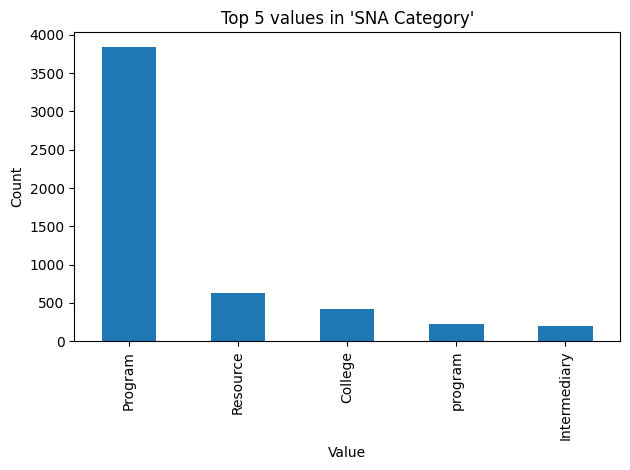

Top 5 after exclusions:
 Title
Executive Director     581
Program Coordinator    295
Program Director       269
President              265
Director               243
Name: count, dtype: int64


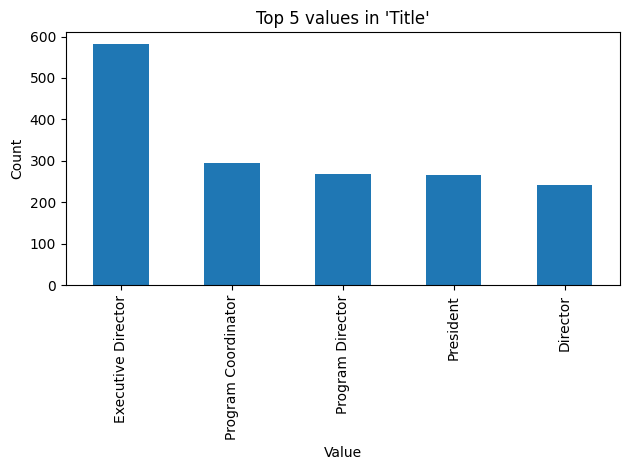

Top 5 after exclusions:
 City
Chicago         9851
Evanston         285
Indianapolis     183
Oak Park         156
Milwaukee        135
Name: count, dtype: int64


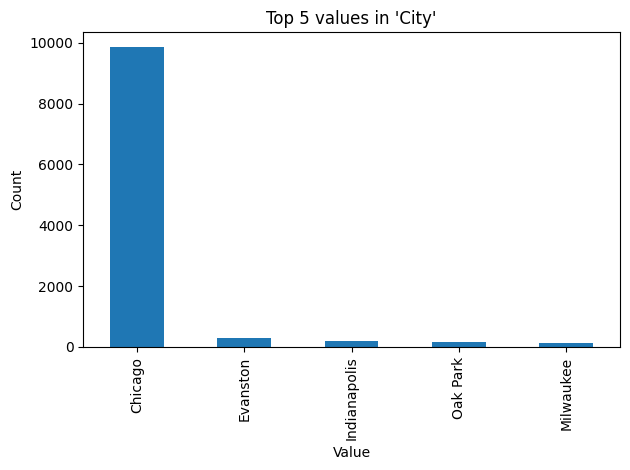

Top 5 after exclusions:
 State
IL     11285
Il       596
IN       269
Il.      244
WI       226
Name: count, dtype: int64


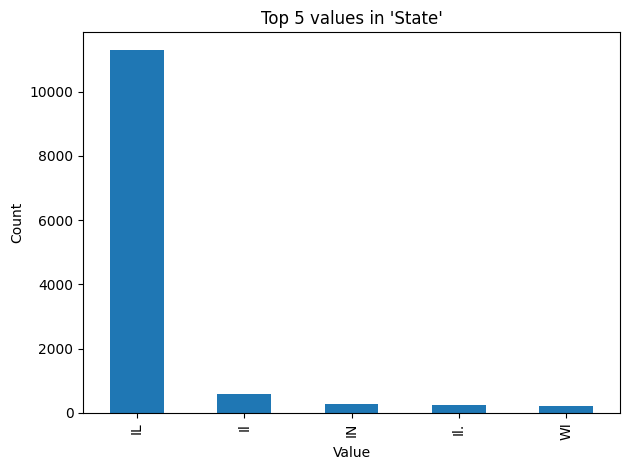

In [124]:
cols = ["SNA Category","Title", "City", "State"]          # <-- change me
exclude_values = {"", "Other"}  # <-- put the two values to drop

# Clean and exclude
for col in cols:
    series = (
        semi_cleaned_df[col]
        .dropna()
        .astype(str).str.strip()
    )

    # Optional: make exclusion case-insensitive
    exclude_ci = {v.casefold() for v in exclude_values}
    series = series[~series.str.casefold().isin(exclude_ci)]

    # Count & take top 5
    counts = series.value_counts()
    top5 = counts.head(5)
    print("Top 5 after exclusions:\n", top5)

    # Plot
    ax = top5.plot(kind="bar")
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")
    ax.set_title(f"Top 5 values in '{col}'")
    plt.tight_layout()
    plt.show()